In [6]:
# # --- Notebook: YOLO + Deep SORT tracking with inline display & counting ---

# import os
# import cv2
# from collections import defaultdict
# from ultralytics import YOLO
# from IPython.display import display, clear_output
# from PIL import Image
# import numpy as np

# # -------- Config --------
# weights = "/home/ubuntu/yolo_training/runs/detect/train/weights/best.pt"         # your trained weights or a pretrained weight path
# source = "/home/ubuntu/Videos/American_Spirit_Black/20251008_141712.mp4"           # video path or webcam index like 0 (int)
# output_path = "output_tracked.mp4"
# tracker_cfg = "deep_sort.yaml" # Ultralytics includes this file
# conf = 0.25
# iou = 0.45
# imgsz = 640
# device = "0"                   # "cpu" or GPU index like "0"
# keep_input_fps = True          # try to preserve input FPS in writer
# display_stride = 2             # show every Nth frame to keep UI responsive
# max_frames = None              # set int to limit frames (e.g., 100); None = full video
# # ------------------------

# # Load model
# model = YOLO(weights)

# # Counters
# seen_ids_global = set()
# seen_ids_per_class = defaultdict(set)

# # Prepare output writer lazily
# writer = None
# os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

# # Detect input FPS for delay/writer
# def get_input_meta(src):
#     cap = cv2.VideoCapture(src if not (isinstance(src, str) and src.isdigit()) else int(src))
#     fps = cap.get(cv2.CAP_PROP_FPS) or 30
#     cap.release()
#     return fps

# input_fps = get_input_meta(source)
# write_fps = input_fps if keep_input_fps and input_fps > 0 else 30

# # Start tracking (Deep SORT under the hood)
# results_stream = model.track(
#     source=source,
#     tracker=tracker_cfg,
#     stream=True,
#     conf=conf,
#     iou=iou,
#     imgsz=imgsz,
#     device=device,
#     persist=True,     # keep track IDs across frames
#     verbose=False
# )

# frame_count = 0
# for i, result in enumerate(results_stream):
#     frame = result.plot()  # annotated BGR frame

#     # Init writer on first frame
#     if writer is None:
#         h, w = frame.shape[:2]
#         fourcc = cv2.VideoWriter_fourcc(*"mp4v")
#         writer = cv2.VideoWriter(output_path, fourcc, write_fps, (w, h))

#     # Update counts
#     boxes = result.boxes
#     if boxes is not None and len(boxes) > 0 and boxes.id is not None:
#         ids = boxes.id.int().tolist()
#         cls = boxes.cls.int().tolist()
#         for tid, c in zip(ids, cls):
#             cname = model.names.get(int(c), str(int(c)))
#             seen_ids_global.add(int(tid))
#             seen_ids_per_class[cname].add(int(tid))

#     # HUD overlay
#     cv2.rectangle(frame, (10, 10), (370, 110), (0, 0, 0), -1)
#     cv2.putText(frame, f"Unique objects: {len(seen_ids_global)}",
#                 (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
#     top = sorted(((k, len(v)) for k, v in seen_ids_per_class.items()),
#                  key=lambda x: x[1], reverse=True)[:3]
#     y = 80
#     for k, v in top:
#         cv2.putText(frame, f"{k}: {v}", (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
#         y += 25

#     # Write video
#     writer.write(frame)

#     # Inline display (every Nth frame)
#     if (i % display_stride) == 0:
#         rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         clear_output(wait=True)
#         display(Image.fromarray(rgb))

#     frame_count += 1
#     if max_frames is not None and frame_count >= max_frames:
#         break

# # Cleanup
# if writer is not None:
#     writer.release()

# # Summary
# print("\n=== Tracking & Counting Summary ===")
# print(f"Saved annotated video to: {os.path.abspath(output_path)}")
# print(f"Total unique objects: {len(seen_ids_global)}")
# if seen_ids_per_class:
#     print("Per-class unique counts:")
#     for cls_name, ids in sorted(seen_ids_per_class.items(), key=lambda x: x[0]):
#         print(f"  {cls_name}: {len(ids)}")
# else:
#     print("No tracks found.")


In [2]:
# import shutil
# from ultralytics.utils import ROOT

# src = ROOT / "cfg/trackers/deep_sort.yaml"
# dst = "deep_sort.yaml"
# shutil.copy(src, dst)
# print("Copied:", dst)


In [1]:
# # --- Notebook: YOLO + ByteTrack tracking with inline display & counting ---

# import os
# import cv2
# from collections import defaultdict
# from ultralytics import YOLO
# from ultralytics.utils import ROOT
# from IPython.display import display, clear_output, Video
# from PIL import Image
# import numpy as np

# # -------- Config --------
# weights = "/home/ubuntu/Annotations/training/runs/detect/train/weights/best.pt"         # your trained weights or a pretrained weight path
# source = "/home/ubuntu/Videos/19_crime_rose/20251013_112042.mp4"           # video path or webcam index like 0 (int)
# output_path = "output_tracked.mp4"
# tracker_cfg = str(ROOT / "cfg/trackers/bytetrack.yaml")  # ByteTrack config shipped with Ultralytics
# conf = 0.25
# iou = 0.45
# imgsz = 640
# device = "0"                    # "cpu" or GPU index as string, e.g., "0"
# keep_input_fps = True
# display_stride = 2              # display every Nth frame inline
# max_frames = None               # set an int to limit frames processed; None = full video
# # ------------------------

# # Optional: quick check that the tracker YAML exists
# if not os.path.exists(tracker_cfg):
#     raise FileNotFoundError(f"ByteTrack config not found at: {tracker_cfg}")

# # Load model
# model = YOLO(weights)

# # Counters
# seen_ids_global = set()
# seen_ids_per_class = defaultdict(set)

# # Prepare output writer lazily
# writer = None
# os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

# def get_input_meta(src):
#     """Return (fps, size) for a video source if available."""
#     if isinstance(src, str) and src.isdigit():
#         cap_src = int(src)
#     else:
#         cap_src = src
#     cap = cv2.VideoCapture(cap_src)
#     fps = cap.get(cv2.CAP_PROP_FPS) or 30
#     w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
#     h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
#     cap.release()
#     size = (w, h) if (w > 0 and h > 0) else None
#     return fps, size

# input_fps, _ = get_input_meta(source)
# write_fps = input_fps if (keep_input_fps and input_fps > 0) else 30

# # Start tracking with ByteTrack
# results_stream = model.track(
#     source=source,
#     tracker=tracker_cfg,   # ByteTrack
#     stream=True,
#     conf=conf,
#     iou=iou,
#     imgsz=imgsz,
#     device=device,
#     persist=True,          # keep track IDs across frames
#     verbose=False
# )

# frame_count = 0
# for i, result in enumerate(results_stream):
#     # Annotated frame (BGR)
#     frame = result.plot()

#     # Initialize writer on first frame
#     if writer is None:
#         h, w = frame.shape[:2]
#         fourcc = cv2.VideoWriter_fourcc(*"mp4v")
#         writer = cv2.VideoWriter(output_path, fourcc, write_fps, (w, h))

#     # Update counts using track IDs from ByteTrack
#     boxes = result.boxes
#     if boxes is not None and len(boxes) > 0 and boxes.id is not None:
#         ids = boxes.id.int().tolist()
#         cls = boxes.cls.int().tolist()
#         for tid, c in zip(ids, cls):
#             cname = model.names.get(int(c), str(int(c)))
#             seen_ids_global.add(int(tid))
#             seen_ids_per_class[cname].add(int(tid))

#     # HUD overlay
#     cv2.rectangle(frame, (10, 10), (370, 110), (0, 0, 0), -1)
#     cv2.putText(frame, f"Unique objects: {len(seen_ids_global)}",
#                 (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
#     top = sorted(((k, len(v)) for k, v in seen_ids_per_class.items()),
#                  key=lambda x: x[1], reverse=True)[:3]
#     y = 80
#     for k, v in top:
#         cv2.putText(frame, f"{k}: {v}", (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
#         y += 25

#     # Write annotated frame
#     writer.write(frame)

#     # Inline display (every Nth frame)
#     if (i % display_stride) == 0:
#         rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         clear_output(wait=True)
#         display(Image.fromarray(rgb))

#     frame_count += 1
#     if max_frames is not None and frame_count >= max_frames:
#         break

# # Cleanup
# if writer is not None:
#     writer.release()

# # Summary + show saved video preview
# print("\n=== Tracking & Counting Summary ===")
# print(f"Saved annotated video: {os.path.abspath(output_path)}")
# print(f"Total unique objects: {len(seen_ids_global)}")
# if seen_ids_per_class:
#     print("Per-class unique counts:")
#     for cls_name, ids in sorted(seen_ids_per_class.items(), key=lambda x: x[0]):
#         print(f"  {cls_name}: {len(ids)}")
# else:
#     print("No tracks found.")

# # Inline player for the saved result (in Jupyter)
# try:
#     display(Video(output_path, embed=True))
# except Exception:
#     pass


In [4]:
import os
import cv2
import numpy as np
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, clear_output
from PIL import Image

# Deep SORT
from deep_sort_realtime.deepsort_tracker import DeepSort

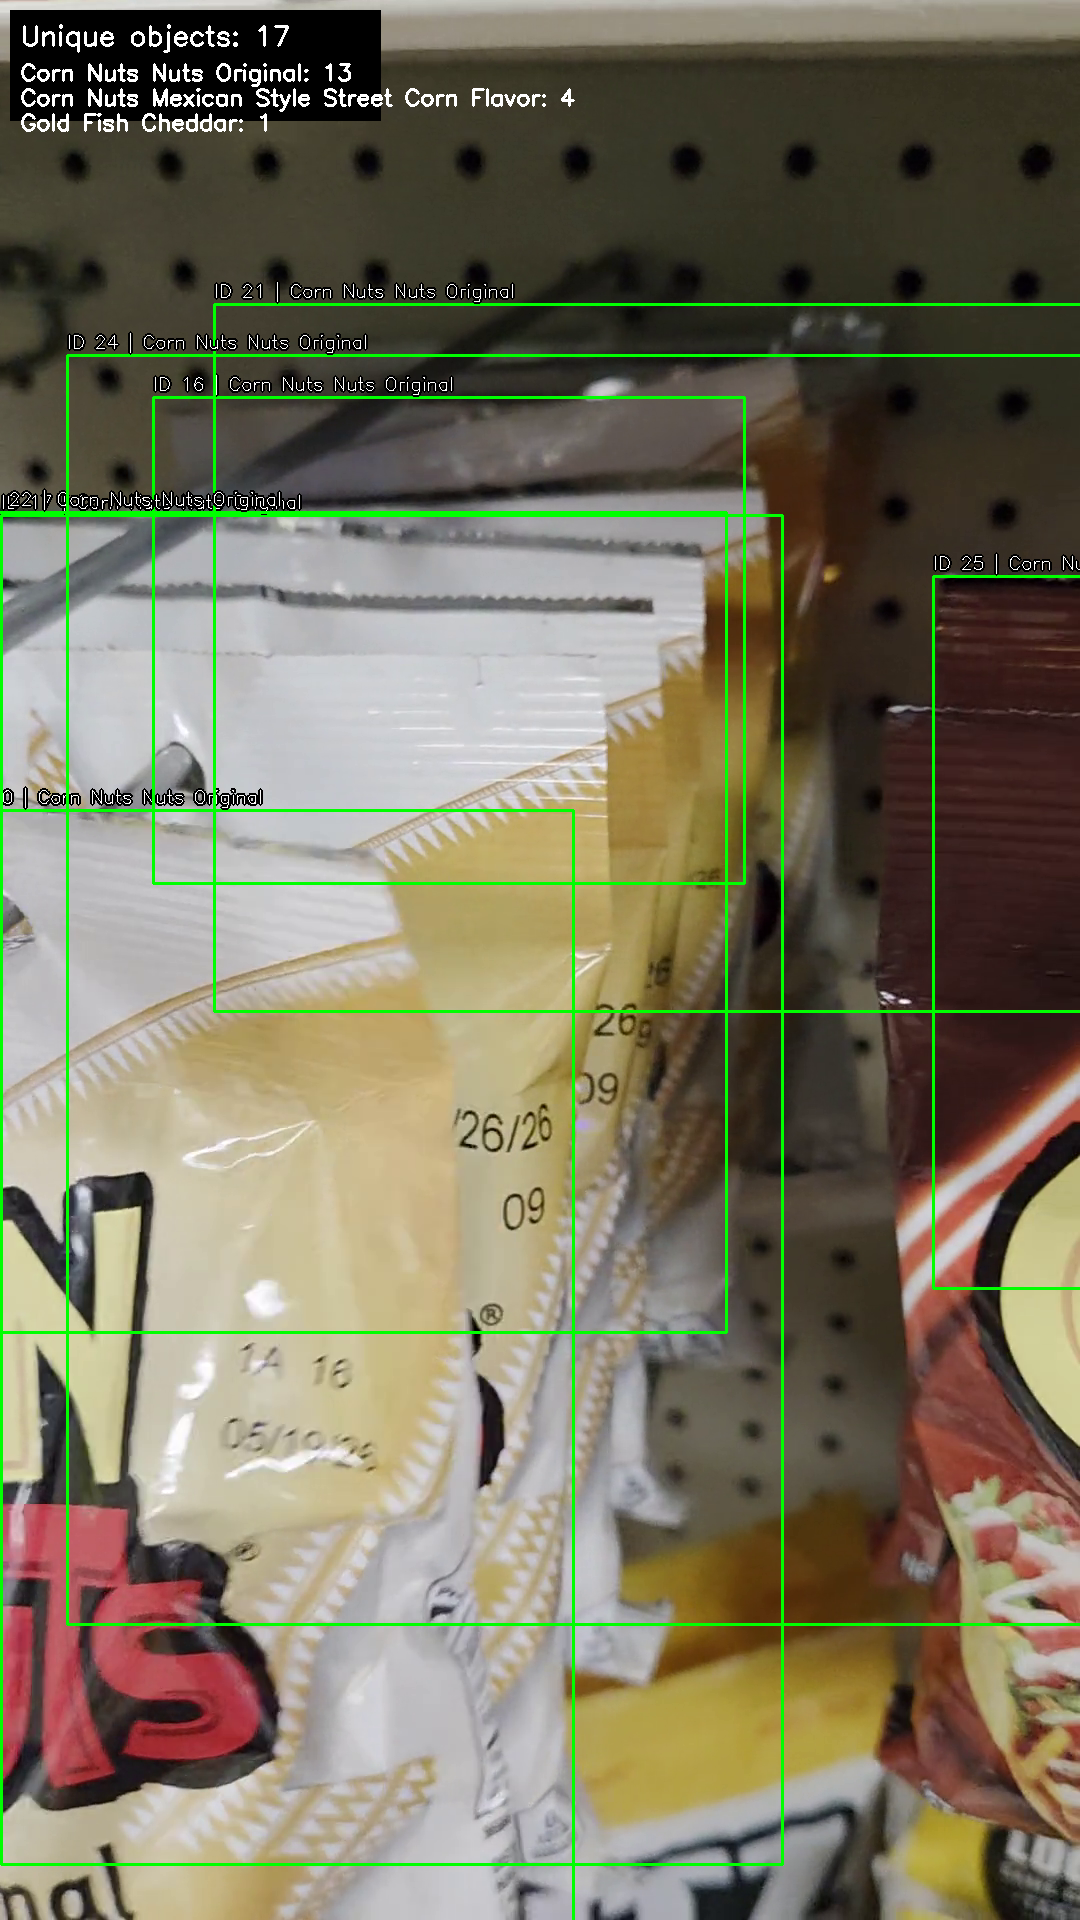

KeyboardInterrupt: 

In [5]:
# YOLO + Deep SORT (deep-sort-realtime) – notebook friendly
import os
import cv2
import numpy as np
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, clear_output
from PIL import Image

# Deep SORT
from deep_sort_realtime.deepsort_tracker import DeepSort

# ---------------- Config ----------------
weights =  '/home/ubuntu/additional_drive/shwan_data/yolo_training/runs/train/yolov11l_merged_new/weights/best.pt' # your trained weights or pretrained checkpoint
source = "Video1_crop.mp4"            # video path or webcam index like 0 (int)
output_path = "output_tracked_new.mp4"

conf = 0.25
iou = 0.45
imgsz = 640
device = "0"                    # "cpu" or GPU index string like "0"

keep_input_fps = True
display_stride = 2              # show every Nth frame for smoother notebooks
max_frames = None               # e.g., 500 to limit; None for full video
# ---------------------------------------

# Load detector
model = YOLO(weights)

# Set up Deep SORT tracker
# Notes:
# - 'embedder' can be "mobilenet" (fast) or "torchreid" (better, heavier).
# - First run may download the ReID model; if offline, use "mobilenet".
tracker = DeepSort(
    max_age=30,
    n_init=3,
    nms_max_overlap=1.0,
    max_cosine_distance=0.2,
    embedder="mobilenet",   # good balance for notebook use
    half=True,
    bgr=True
)

# Video writer will be created lazily on first frame
writer = None
os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

def get_input_meta(src):
    cap = cv2.VideoCapture(src if not (isinstance(src, str) and src.isdigit()) else int(src))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 0
    h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 0
    cap.release()
    return fps, (w, h)

input_fps, _ = get_input_meta(source)
write_fps = input_fps if keep_input_fps and input_fps > 0 else 30

# Counting structures
seen_ids_global = set()
seen_ids_per_class = defaultdict(set)

# Run YOLO in streaming mode over frames
results_stream = model.predict(
    source=source,
    stream=True,
    conf=conf,
    iou=iou,
    imgsz=imgsz,
    device=device,
    verbose=False
)

frame_idx = 0
for result in results_stream:
    frame = result.orig_img  # original BGR frame
    if frame is None:
        continue

    # Build detections for Deep SORT: [[x1,y1,x2,y2], conf, class_name]
    dets = []
    if result.boxes is not None and len(result.boxes) > 0:
        xyxy = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        clss  = result.boxes.cls.cpu().numpy().astype(int)
        for (x1, y1, x2, y2), cf, ci in zip(xyxy, confs, clss):
            class_name = model.names.get(int(ci), str(int(ci)))
            dets.append([ [float(x1), float(y1), float(x2), float(y2)], float(cf), class_name ])

    # Update tracker
    tracks = tracker.update_tracks(dets, frame=frame)  # returns list of Track objects

    # Draw tracks and update counts
    for t in tracks:
        if not t.is_confirmed():
            continue
        tid = int(t.track_id)
        ltrb = t.to_ltrb()  # left, top, right, bottom
        x1, y1, x2, y2 = map(int, ltrb)

        # Class name from last detection (if available)
        cls_name = None
        if t.get_det_class() is not None:
            cls_name = str(t.get_det_class())

        # Count unique IDs (global and per class if we have it)
        seen_ids_global.add(tid)
        if cls_name:
            seen_ids_per_class[cls_name].add(tid)

        # Draw box + id
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"ID {tid}" + (f" | {cls_name}" if cls_name else "")
        cv2.putText(frame, label, (x1, max(0, y1-7)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
        cv2.putText(frame, label, (x1, max(0, y1-7)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    # HUD overlay: running counts
    cv2.rectangle(frame, (10, 10), (380, 120), (0, 0, 0), -1)
    cv2.putText(frame, f"Unique objects: {len(seen_ids_global)}",
                (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    top = sorted(((k, len(v)) for k, v in seen_ids_per_class.items()),
                 key=lambda x: x[1], reverse=True)[:3]
    y = 80
    for k, v in top:
        cv2.putText(frame, f"{k}: {v}", (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
        y += 25

    # Create writer on first frame
    if writer is None:
        h, w = frame.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_path, fourcc, write_fps, (w, h))

    writer.write(frame)

    # Inline preview every Nth frame
    if (frame_idx % display_stride) == 0:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))

    frame_idx += 1
    if max_frames is not None and frame_idx >= max_frames:
        break

# Cleanup
if writer is not None:
    writer.release()

# Summary
print("\n=== Deep SORT Tracking & Counting Summary ===")
print(f"Saved annotated video to: {os.path.abspath(output_path)}")
print(f"Total unique objects: {len(seen_ids_global)}")
if seen_ids_per_class:
    print("Per-class unique counts:")
    for cls_name, ids in sorted(seen_ids_per_class.items(), key=lambda x: x[0]):
        print(f"  {cls_name}: {len(ids)}")
else:
    print("No tracks found.")


In [ ]:
https://chatgpt.com/share/68f6539b-112c-8002-8d31-2d0d2f7e43ads

In [ ]:
https://chatgpt.com/share/68f6554d-cba8-8002-a336-84bd65e10e88

In [ ]:
eyJhbGciOiJkaXIiLCJlbmMiOiJBMjU2R0NNIn0..bYds9TDBcASK3AB0.rCrMcC5-MGVu3I01Xjnv3m-C50clvNsmxVet7cZ_9f8zGYruD3cH4OKmXF_Af6X67kXU6ydFTsM_rBpTWv_haEvfJo8nhjJoecVju1ZJS8Q5DxphTPy9VcYgyFf8lxk5bmYqxwPG0WRYlZrkV6poibCaPuk7b4Y05FSdARfA2zab9CbL-CTALPj7C_241LWdw8IKccJrWVkr9Szq88QhktSADSTl3VtQbJMhBI9IusbEOoDZJnVqfi-pZ0i73PxjJx0lsj9q38N9wi9-W88MNY5m0R78DDXp90n1K7I3EAtUuDSdwl96BtENDxod3JWbZFQoX5UdO_ZXHxU5FPwNstyOCP9wxq35e0FhEHrsFzWGJIW0aYnw9itUBpiSNJQq33FdGFb2KHeouZENY5mbVbP62Rg2U5mjRfbEEIXrXqoQe4btsqCcmuOIVzqgQmayL9wcfckLb-eK_9ME-CrOsCykZ9LIjZhzjQzzq0NWfEvZgdFtwIatnSERlDdG3kKIu4Urh4V3ddb3ksK6EsaFICSw67SPS8CpGJcSw7B3e1A9W91aGJOqNoqDa3b3Cv0VN6M8T4QjIkPA7wthfKHBA855ftBg6ygWJTnM_xUjqv2O6v55pDUqZu0Xl_dL8CBwk92vBtxIkt5mCkyr_Vst0_tXlZF_oDJdgNrLDHQ0zTtkI-cMwMumWRI_0a5hBNOFO9EiPAwzGxvQAm7hc71k33DR2fYNDphVqgcVzj2aHM3mTSDi-mLgISr1i-ZqwVEc2qOccPWVN49vahM7TijnW7GmKEN1A9W8y7BenA5mtz0tDljY7gkvCBo3YaYkxjyjvhGfdB6Ejr-xmNEsu3Dkeel7ldM6ktes9qGHZAj9jsZPMnMYx4JdbO9uT7yiu4mxbd01jBfL8RXc4YFjKRhnVRD439trTAk3HjkWxj5Rw3HzEyytnkRLsLRM5rONdwLD5ZCdoPtjKyRAaXIkq3KWuWns9xyamTDgQspAmIIEPRQztejjhkG9ttd_iBbJYlG1msLbGN4o6_a6hkIrF-ovI2vs4KIJvDoX6VtYoTA4kAOh8cWmeqkFe7dSu4peqj4f6Pp507YYzMwCe6hURSnCw1EXktwr4A3D5qHetHiJWjVAUL_SzxcWTwcFtUS3DQIVzM2WxOKKeuLyjhejfjvgzrvzGsjvd96uTCA-aNWU69wxZ_3K4R4TuE9NNSzZvHgdbi6O018qMFf_5beJD4P7QoxrdYS-cQMA4uLwIk0TTUta49Jioqom5ZCiVmESauDPAXnY5cVnX_ij9XarmsCeBtOPGRC-jkNdzi-5tW3uLeAcb2Q0H-z5jhsZy3e4_Kt0H_wkrDm3Ic2Q67243SOmXoKQqJo7hex7AvGIU3DXB5JfHLDvM930o5tc3FkXl2dNjIy28vFFTRsbL2weXsxU_syaogjFnYIm2jVqfc7CYp8Cl7awhr5LkMANysLYu4eSQlNVkvwII-Fz8ycKqfd1Rmy0WLNkUdqIrhTDO0F8cmyGpJdpWCa0iRSidGu5GTq3d_nauK-VfY9uEzf5nQYcGDMCzkPVWy7VSP-Ql0laHbWYDattzNZmomt_KaL2TRXCWTrJZqhi2_aXjxalvCZOQLFJu7rLnyf6N6Ld9T65CiUEN68OhvfVJOL5lXp5wqJWCmRIIjaAu7BKQol3C5zEOzNVMrOn5BI02tNtNm9UwQyMa1bO7nCy67S-NP2j6GsPfVgXMNBgRN6mKWFULxxOmKkpwWbqfENdDf2EpSiCmj72eGRpRbkuozBlukip02-8DFcsO-nszZx6NybSu4nQ4g_eJlRkbvWNaq9Y9eWakB1lJFp7IWmRHRVwFOXE7RnOeTb-Outc_m47UfikD2f-b3ILNY5kCZMy7vfGqRPubAAxHmvxBsgQ17gwIJ9T7kzqYTHj7jbrYHwwrQ7ksW8YZs-lhXU6SD1CLiqHVULiNshSJq7mn7nOv6X4T8h65Dvm2ge63hzdZi6cGmMWJqCdrYxV9ak_rwDHDEOgLHkAibq7SfkSFMC9ycLR2w9orpGMasK_r0l7bEZIYdNWN3oCW16Nf4H-YwLw2o-e-58BRh3J1lxyCDmMB6p5ZWycImyLYYu9DNphv1Q7P1HnJDIfWnKzDH1Ztw0ES3WJnP-Ro67NqV2u3plIOFLRE0NYYtmtIbl33KBUUKTc20rW9lx-hi43O_mNOwakiUFLOAiib2FC_4EibRIPcTPWf5hA1-zMeFFr6X_vTjrAVp3jciFPvhS1Of8S0MA3gqppfQm3MGrXuTuOp7-FCc1TBAVCIArPbjWfeT-MWa3_ROvpCEluYu9WL9xQpYbtIcJn8N08iDCeQJaH3tppOf9d23HanrF0bjG3nbNPFZwjHOElDq_YzfDuU2BhB6lm8WEYZNZKUgIXA-Tcdon9rGBwZXFzIF3QQXABShSuQ5JP1oWDGgEuoD1JWNW2pghdj-SkIYZmlY4hB-gJtpYx8MiLCNbAZ9YfMaUsk59ndigfWg5Ee0lwyPpd7_h9v3az2mwvWCxEK-aB7FwMgfQpQVe0F4rJaO8EBEmBJNjbb-v19GYF6drfKNocgVX5A6gDC72rVPq0U_JMqj1D4H5NHd6suO69ZKFlQtYKQVVm2qTYTkNOf_MI3rSjhJKZx3Z2YpyxZqaFjqR1V8jy3tSdX73M8k3Z4delq42qGXy9HFbfucY1AByQsyBDwREV-Zhd_mp7xc3gbDR9yX0-jcr8eGUr530KRlAHnLmnXS3pU53lZaYK70FqbKX2izfrZ2qoRsoy7vO0RhbKVmfq8kqz3W7ddThh_o_oeDpcdYH4E6wE3zBbQQFD8dNtoFuPYukVVnqFSX9Qqlczb_UoNG4Q-B9u297dlcqgP2nN_Y9Xwzohhhm6EP7g4dEe0344qvwRyM6LbbPaTP6QvNO0tuzKs32VfAbo2ANJOerv46Ps7VYfhcudW0j8aiSvbwiGjfw.eqrcaloPz2HBlSDgkF43NA

## Clean Notebook

In [11]:
import requests
from tqdm import tqdm

# === Configuration ===
SERVER_URL = "http://145.223.103.170:8833/video"
OUT_PATH = "Video1.mp4"
# =====================

# Stream download
with requests.get(SERVER_URL, stream=True) as r:
    r.raise_for_status()
    total = int(r.headers.get("Content-Length", 0))
    with open(OUT_PATH, "wb") as f, tqdm(
        total=total, unit="B", unit_scale=True, desc="Downloading Video1.mp4"
    ) as pbar:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

print("✅ File downloaded to:", OUT_PATH)


✅ File downloaded to: Video1.mp4


In [6]:
from moviepy import VideoFileClip

input_path  = "Video1.mp4"
output_path = "Video1_crop.mp4"
start_time  = 5     # in seconds
end_time    = 15    # up to 15s

clip = VideoFileClip(input_path)

# Option A: use slicing
cropped = clip[start_time:end_time]

# Option B: use the renamed method
#   cropped = clip.subclipped(start_time, end_time)

cropped.write_videofile(output_path,
                        codec="libx264",
                        audio_codec="aac")

clip.close()
cropped.close()

print("✅ Saved:", output_path)


MoviePy - Building video Video1_crop.mp4.
MoviePy - Writing audio in Video1_cropTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
MoviePy - Writing video Video1_crop.mp4



MoviePy - Done !
MoviePy - video ready Video1_crop.mp4
✅ Saved: Video1_crop.mp4
